INITIAL DATA OVERVIEW
Dataset shape: (328, 5)

First 5 rows:
                                               title            price  \
0  Essential Math for Data Science: Take Control ...           $29.00   
1  Becoming a Data Head: How to Think, Speak, and...           $24.49   
2  Ace the Data Science Interview: 201 Real Inter...  $34.30 - $36.26   
3  Data Science from Scratch: First Principles wi...  $39.97 - $52.18   
4  Practical Statistics for Data Scientists: 50+ ...  $24.90 - $29.00   

               rating      reviews          author  
0  4.5 out of 5 stars  117 ratings    Thomas Nield  
1  4.6 out of 5 stars  250 ratings  Alex J. Gutman  
2  4.5 out of 5 stars  778 ratings      Nick Singh  
3  4.4 out of 5 stars  638 ratings       Joel Grus  
4  4.6 out of 5 stars  673 ratings     Peter Bruce  

Data types:
title      object
price      object
rating     object
reviews    object
author     object
dtype: object

Missing values:
title       0
price      37
rating      0
review

/tmp/ipykernel_1059/3317264071.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(price_by_target, labels=high_rated_labels, patch_artist=True)
/tmp/ipykernel_1059/3317264071.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(reviews_by_target, labels=high_rated_labels, patch_artist=True)


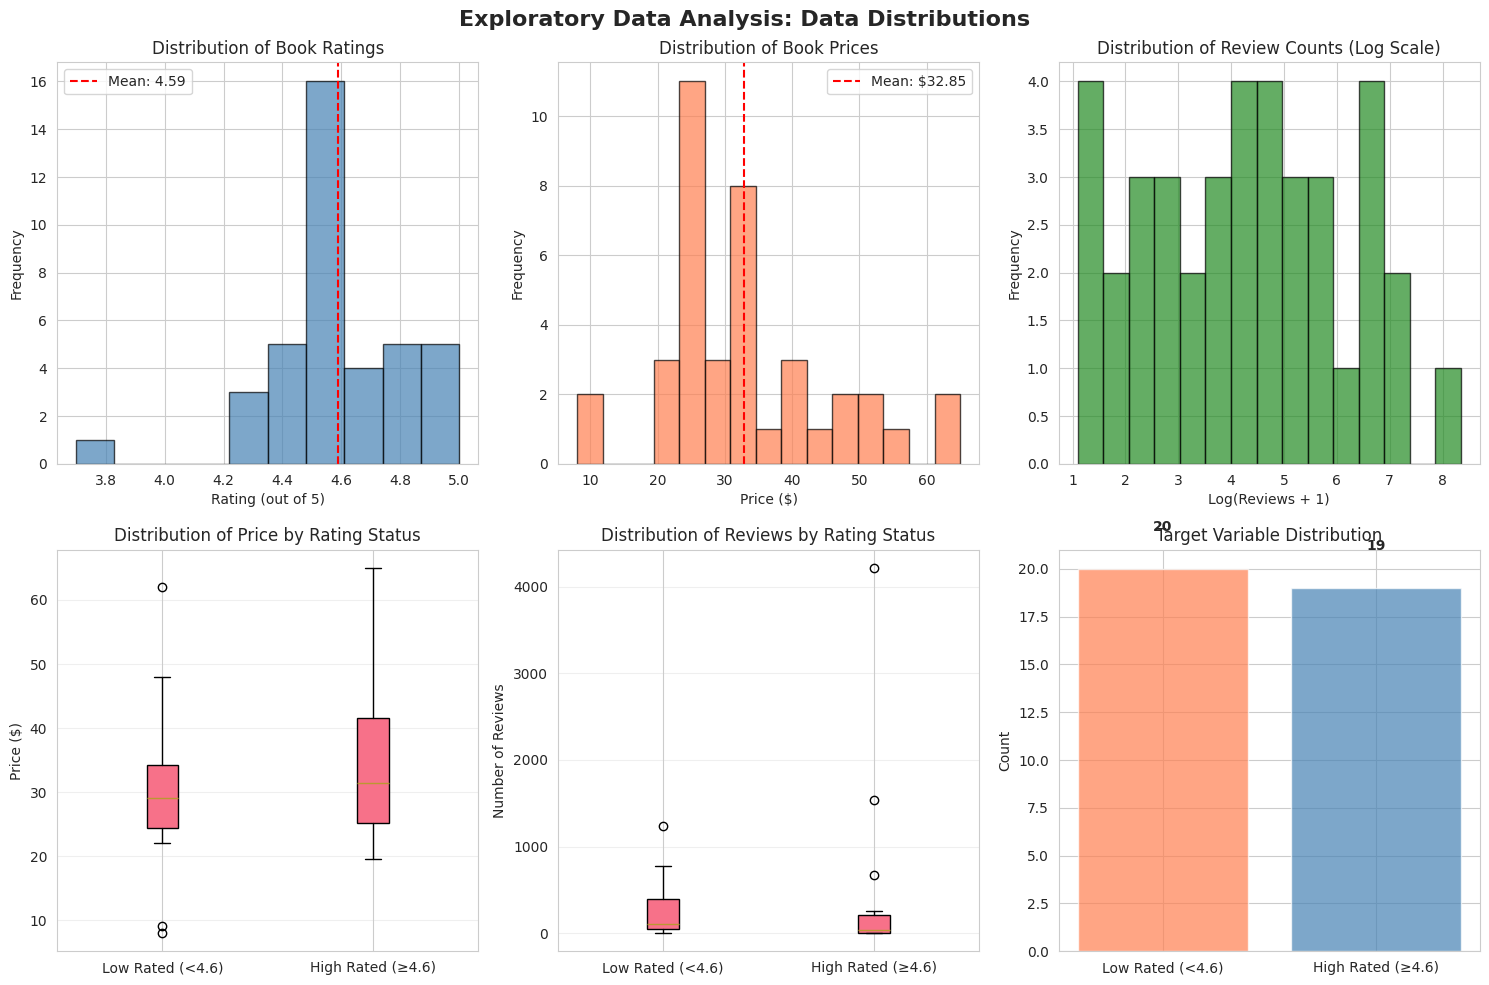

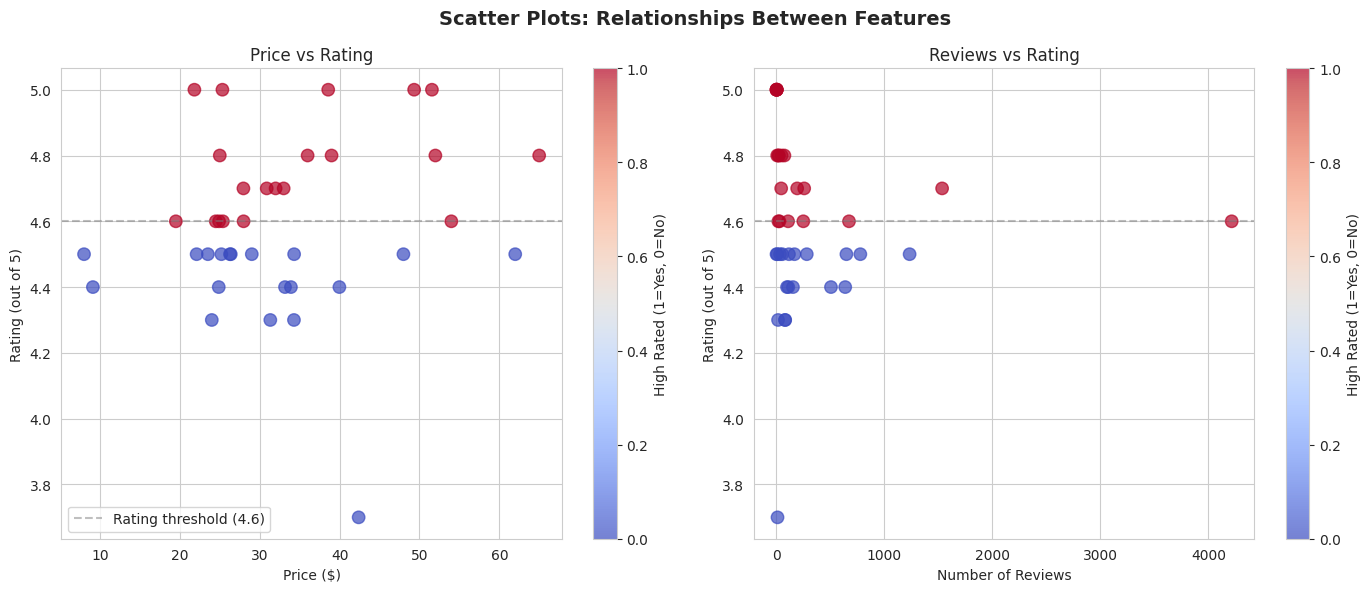

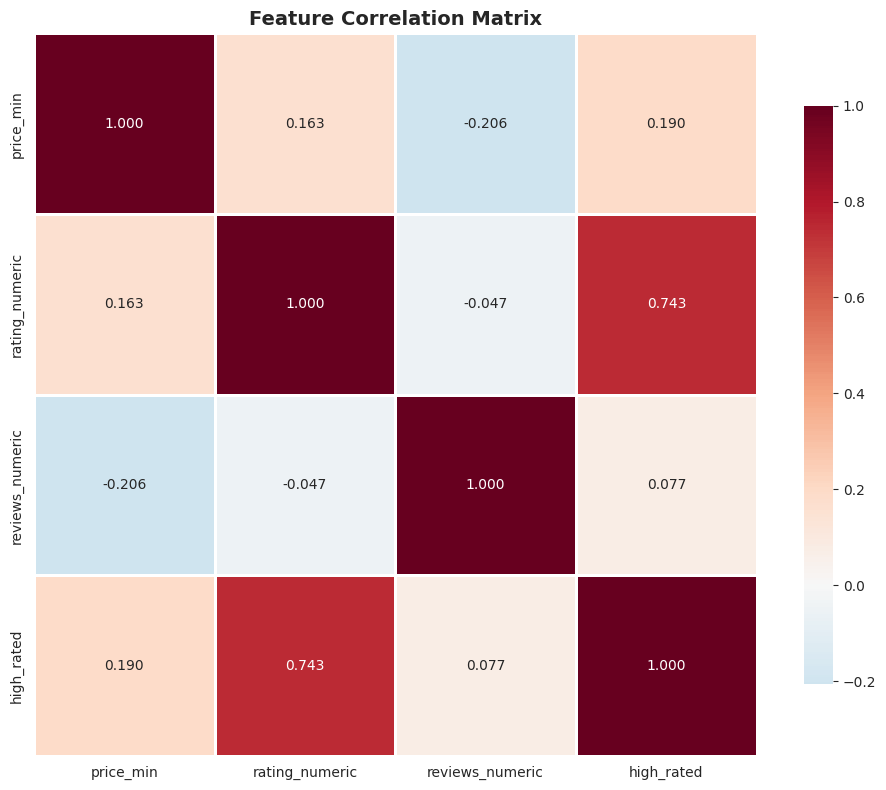


CORRELATION ANALYSIS
Correlation with target variable (high_rated):
high_rated         1.000000
rating_numeric     0.743057
price_min          0.190485
reviews_numeric    0.077471
Name: high_rated, dtype: float64

FEATURE SELECTION RESULTS (ANOVA F-test)
           Feature   F-Score   P-Value
0        price_min  1.393074  0.245419
1  reviews_numeric  0.223406  0.639233

MODEL TRAINING - LOGISTIC REGRESSION
Training set size: 27 samples
Test set size: 12 samples

MODEL EVALUATION METRICS
Accuracy: 0.4167

Classification Report:
                   precision    recall  f1-score   support

 Low Rated (<4.6)       0.43      0.50      0.46         6
High Rated (≥4.6)       0.40      0.33      0.36         6

         accuracy                           0.42        12
        macro avg       0.41      0.42      0.41        12
     weighted avg       0.41      0.42      0.41        12

Confusion Matrix:
             Predicted Low  Predicted High
Actual Low               3               3
Actua

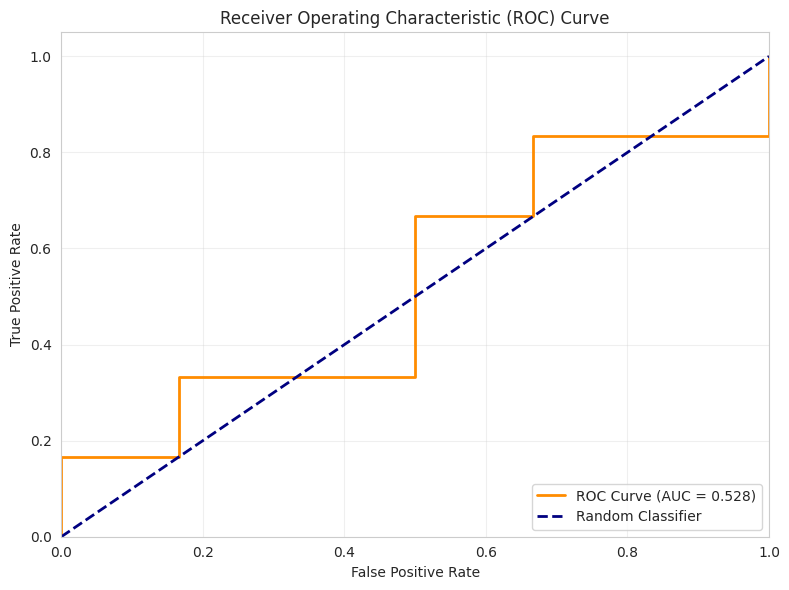

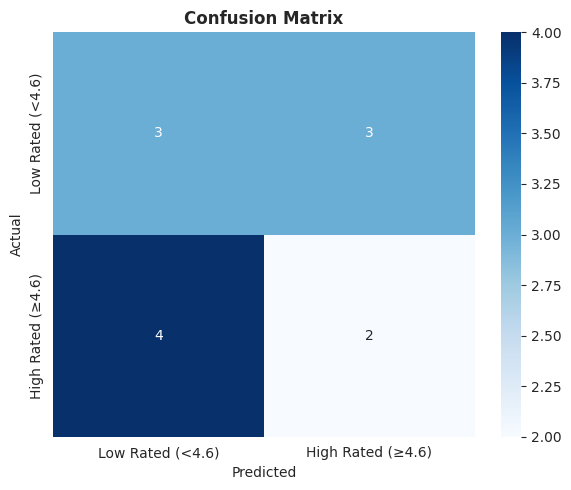


SUMMARY STATISTICS

Descriptive statistics of cleaned dataset:
       price_min  reviews_numeric  rating_numeric  high_rated
count  39.000000        39.000000       39.000000   39.000000
mean   32.851282       321.589744        4.589744    0.512821
std    12.693124       727.982711        0.252143    0.506370
min     7.990000         2.000000        3.700000    0.000000
25%    24.945000        17.500000        4.500000    0.000000
50%    30.870000        81.000000        4.600000    1.000000
75%    38.780000       254.000000        4.750000    1.000000
max    64.990000      4216.000000        5.000000    1.000000

Analysis Complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, f_classif

# ============================================================================
# 1. DATA LOADING AND INITIAL INSPECTION
# ============================================================================

# Load the dataset
df = pd.read_csv('/content/amazon_data_science_books.csv')

print("=" * 80)
print("INITIAL DATA OVERVIEW")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

# ============================================================================
# 2. DATA CLEANING AND FEATURE ENGINEERING
# ============================================================================

def extract_min_price(price_str):
    """Extract minimum price from price string"""
    if pd.isna(price_str) or price_str == '':
        return np.nan
    # Remove dollar sign and any spaces
    price_str = str(price_str).replace('$', '').strip()
    if '-' in price_str:
        # Extract the lower bound of price range
        min_price = float(price_str.split('-')[0].strip())
    else:
        min_price = float(price_str)
    return min_price

def extract_rating(rating_str):
    """Extract numeric rating from rating string"""
    if pd.isna(rating_str) or rating_str == 'Previous page':
        return np.nan
    # Extract number before 'out of'
    rating_str = str(rating_str)
    if 'out of' in rating_str:
        return float(rating_str.split('out of')[0].strip())
    return np.nan

def extract_reviews(reviews_str):
    """Extract numeric review count from reviews string"""
    if pd.isna(reviews_str) or reviews_str == 'Previous page':
        return np.nan
    # Remove commas and the word 'ratings'
    reviews_str = str(reviews_str).replace(',', '').replace('ratings', '').strip()
    try:
        return int(reviews_str)
    except:
        return np.nan

# Apply cleaning functions
df['price_min'] = df['price'].apply(extract_min_price)
df['rating_numeric'] = df['rating'].apply(extract_rating)
df['reviews_numeric'] = df['reviews'].apply(extract_reviews)

# Create target variable: High rating (1 if rating >= 4.6, else 0)
df['high_rated'] = (df['rating_numeric'] >= 4.6).astype(float)

# Remove duplicates based on title
df = df.drop_duplicates(subset=['title'], keep='first')

# Drop rows with missing target or key features
df_clean = df.dropna(subset=['high_rated', 'price_min', 'rating_numeric', 'reviews_numeric'])

print("\n" + "=" * 80)
print("DATA CLEANING SUMMARY")
print("=" * 80)
print(f"Original rows: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Target distribution:\n{df_clean['high_rated'].value_counts()}")
print(f"Target distribution (percentage):\n{df_clean['high_rated'].value_counts(normalize=True) * 100}")

# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS - VISUALISATIONS
# ============================================================================

sns.set_style("whitegrid")
sns.set_palette("husl")

# Figure 1: Distribution of Rating (Data Distribution Graph)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis: Data Distributions', fontsize=16, fontweight='bold')

# 1.1 Distribution of ratings
axes[0, 0].hist(df_clean['rating_numeric'], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Rating (out of 5)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Book Ratings')
axes[0, 0].axvline(df_clean['rating_numeric'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["rating_numeric"].mean():.2f}')
axes[0, 0].legend()

# 1.2 Distribution of price
axes[0, 1].hist(df_clean['price_min'], bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Book Prices')
axes[0, 1].axvline(df_clean['price_min'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["price_min"].mean():.2f}')
axes[0, 1].legend()

# 1.3 Distribution of review counts (log scale for better visualisation)
axes[0, 2].hist(np.log1p(df_clean['reviews_numeric']), bins=15, edgecolor='black', alpha=0.7, color='forestgreen')
axes[0, 2].set_xlabel('Log(Reviews + 1)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Review Counts (Log Scale)')

# 1.4 Box plot: Price by High Rating Status (Distribution of Mean Radius by Target analogue)
high_rated_labels = ['Low Rated (<4.6)', 'High Rated (≥4.6)']
price_by_target = [df_clean[df_clean['high_rated'] == 0]['price_min'],
                   df_clean[df_clean['high_rated'] == 1]['price_min']]
axes[1, 0].boxplot(price_by_target, labels=high_rated_labels, patch_artist=True)
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].set_title('Distribution of Price by Rating Status')
axes[1, 0].grid(axis='y', alpha=0.3)

# 1.5 Box plot: Reviews by High Rating Status
reviews_by_target = [df_clean[df_clean['high_rated'] == 0]['reviews_numeric'],
                      df_clean[df_clean['high_rated'] == 1]['reviews_numeric']]
axes[1, 1].boxplot(reviews_by_target, labels=high_rated_labels, patch_artist=True)
axes[1, 1].set_ylabel('Number of Reviews')
axes[1, 1].set_title('Distribution of Reviews by Rating Status')
axes[1, 1].grid(axis='y', alpha=0.3)

# 1.6 Count plot of target variable
target_counts = df_clean['high_rated'].value_counts()
axes[1, 2].bar(['Low Rated (<4.6)', 'High Rated (≥4.6)'], target_counts.values, alpha=0.7, color=['coral', 'steelblue'])
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Target Variable Distribution')
for i, v in enumerate(target_counts.values):
    axes[1, 2].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 4. SCATTER PLOT
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Scatter Plots: Relationships Between Features', fontsize=14, fontweight='bold')

# Scatter plot: Price vs Rating (coloured by High Rating status)
scatter1 = axes[0].scatter(df_clean['price_min'], df_clean['rating_numeric'],
                           c=df_clean['high_rated'], cmap='coolwarm', alpha=0.7, s=80)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Rating (out of 5)')
axes[0].set_title('Price vs Rating')
axes[0].axhline(y=4.6, color='gray', linestyle='--', alpha=0.5, label='Rating threshold (4.6)')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='High Rated (1=Yes, 0=No)')

# Scatter plot: Reviews vs Rating (coloured by High Rating status)
scatter2 = axes[1].scatter(df_clean['reviews_numeric'], df_clean['rating_numeric'],
                           c=df_clean['high_rated'], cmap='coolwarm', alpha=0.7, s=80)
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Rating (out of 5)')
axes[1].set_title('Reviews vs Rating')
axes[1].axhline(y=4.6, color='gray', linestyle='--', alpha=0.5)
plt.colorbar(scatter2, ax=axes[1], label='High Rated (1=Yes, 0=No)')

plt.tight_layout()
plt.show()

# ============================================================================
# 5. FEATURE CORRELATION MATRIX
# ============================================================================

# Select numeric features for correlation
correlation_features = ['price_min', 'rating_numeric', 'reviews_numeric', 'high_rated']
df_corr = df_clean[correlation_features].copy()

# Calculate correlation matrix
corr_matrix = df_corr.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)
print("Correlation with target variable (high_rated):")
print(corr_matrix['high_rated'].sort_values(ascending=False))

# ============================================================================
# 6. FEATURE SELECTION
# ============================================================================

# Prepare feature matrix X and target vector y
feature_cols = ['price_min', 'reviews_numeric']
X = df_clean[feature_cols].copy()
y = df_clean['high_rated'].copy()

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection using SelectKBest (ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)

# Display feature scores
print("\n" + "=" * 80)
print("FEATURE SELECTION RESULTS (ANOVA F-test)")
print("=" * 80)
feature_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
})
print(feature_scores.sort_values('F-Score', ascending=False))

# ============================================================================
# 7. MODEL TRAINING AND EVALUATION
# ============================================================================

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print("\n" + "=" * 80)
print("MODEL TRAINING - LOGISTIC REGRESSION")
print("=" * 80)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Train logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Model evaluation
print("\n" + "=" * 80)
print("MODEL EVALUATION METRICS")
print("=" * 80)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Rated (<4.6)', 'High Rated (≥4.6)']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, columns=['Predicted Low', 'Predicted High'], index=['Actual Low', 'Actual High']))

# Model coefficients
print("\n" + "=" * 80)
print("MODEL COEFFICIENTS")
print("=" * 80)
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_reg.coef_[0]
})
print(coefficients)
print(f"Intercept: {log_reg.intercept_[0]:.4f}")

# ============================================================================
# 8. ADDITIONAL VISUALISATIONS: ROC CURVE
# ============================================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 9. CONFUSION MATRIX VISUALISATION
# ============================================================================

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Rated (<4.6)', 'High Rated (≥4.6)'],
            yticklabels=['Low Rated (<4.6)', 'High Rated (≥4.6)'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 10. SUMMARY STATISTICS OUTPUT
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print("\nDescriptive statistics of cleaned dataset:")
print(df_clean[feature_cols + ['rating_numeric', 'high_rated']].describe())

print("\nAnalysis Complete!")